# Zero-Shot Evaluation — `microsoft/trocr-base-handwritten` on our line-crop transcriptions

Runs the **base** TrOCR handwritten model **with no fine-tuning** and reports CER / WER on a
held-out **test set**. The data is split three ways:

| Split | Source | Used for |
|-------|--------|----------|
| **train** | every page **except** the last of each book | fine-tuning (later stage) |
| **val** | the **last page of each book** (this used to be the test set) | early stopping & model selection |
| **test** | the dedicated `test_set_line_crops/` folder (one fresh page per book) | the zero-shot score |

**Why this layout:** the last-page-per-book split was previously the *test* set. Now that there is a
dedicated `test_set_line_crops/` folder, those last pages are repurposed as the **validation** set —
the model never trains on them, and during fine-tuning they drive **early stopping** (stop when val
CER stops improving) and best-checkpoint selection. The `test_set_line_crops/` pages are kept
untouched for the final, unbiased test number.

Book + page are parsed from each file name with one regex `B(\d)_P_?(\d+)`, so all the different
directory conventions in the dataset work, including the test folder (`B1_P_206/B1_P206_L01.jpg`).

This notebook **completes the zero-shot test** (base model on the test set) and reports a val
baseline. The optional fine-tune section at the end shows how `val_df` wires into early stopping;
it is gated behind `RUN_FINETUNE = False` so nothing trains unless you ask for it.

**Run on a Colab GPU runtime** (Runtime → Change runtime type → **L4 GPU**).

In [1]:
# Colab has torch + transformers; evaluate/jiwer are needed for CER/WER.
!pip -q install evaluate jiwer

In [2]:
import os
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import evaluate

from glob import glob
from collections import defaultdict
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, default_data_collator

plt.rcParams["figure.figsize"] = (12, 4)

# Mount Drive
Upload the `transcriptions/` folder (with `test_set_line_crops/` inside it) to your Drive, then point
`TRANSCRIPTIONS_DIR` at it below.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_TYPE = device.type
print(f"Using device: {device}  (type: {DEVICE_TYPE})")
if DEVICE_TYPE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected — generation will be slow; select an L4 GPU runtime.")

Using device: cuda  (type: cuda)
GPU: NVIDIA L4


# Config

In [5]:
# --- Model: the base handwritten TrOCR, evaluated zero-shot (no fine-tuning) ---
BASE_MODEL = "microsoft/trocr-base-handwritten"

# --- Data: the transcriptions folder uploaded to Drive (adjust if your path differs) ---
TRANSCRIPTIONS_DIR = "/content/drive/MyDrive/transcriptions"

# The dedicated test set folder (one fresh page per book). It lives inside TRANSCRIPTIONS_DIR and
# is EXCLUDED from the train/val pool so it stays a clean, held-out test.
TEST_DIRNAME = "test_set_line_crops"
TEST_SET_DIR = os.path.join(TRANSCRIPTIONS_DIR, TEST_DIRNAME)

# Where to save the train/val/test split tables for re-use (e.g. a later fine-tune).
SPLIT_OUT_DIR = "/content/drive/MyDrive/transcriptions_splits"

# --- Generation / batching ---
MAX_TARGET_LENGTH = 128
BATCH_SIZE        = 8
NUM_BEAMS         = 4
MAX_EVAL_LINES    = None   # cap eval lines for a quick run; None = all

print("Model    :", BASE_MODEL)
print("Data     :", TRANSCRIPTIONS_DIR)
print("Test set :", TEST_SET_DIR)
assert os.path.isdir(TRANSCRIPTIONS_DIR), f'Not found: {TRANSCRIPTIONS_DIR} — check the Drive path'
assert os.path.isdir(TEST_SET_DIR), f'Not found: {TEST_SET_DIR} — check the Drive path'

Model    : microsoft/trocr-base-handwritten
Data     : /content/drive/MyDrive/transcriptions
Test set : /content/drive/MyDrive/transcriptions/test_set_line_crops


# Build the train / val / test split

Each `.jpg` crop is paired with its `.txt`. The **train+val pool** is everything under
`transcriptions/` *except* the `test_set_line_crops/` folder; within that pool the **last (max) page
of each book becomes the validation set** and the rest is train. The **test set** is read separately
from `test_set_line_crops/`.

In [6]:
def build_rows(jpg_list):
    """Pair each .jpg with its .txt; parse book + page from the file name."""
    rows, unmatched = [], []
    for p in jpg_list:
        m = re.match(r'B(\d)_P_?(\d+)', os.path.basename(p))
        if not m:
            unmatched.append(os.path.basename(p))
            continue
        txt = p[:-4] + '.txt'
        if not os.path.exists(txt):
            continue
        with open(txt, encoding='utf-8') as f:
            text = f.read().strip()
        if not text:
            continue
        rows.append({'file_name': p, 'text': text,
                     'book': 'B' + m.group(1), 'page': int(m.group(2))})
    return rows, unmatched

all_jpg = sorted(glob(os.path.join(TRANSCRIPTIONS_DIR, '**', '*.jpg'), recursive=True))
# train+val pool = everything that is NOT inside the held-out test folder
trainval_jpg = [p for p in all_jpg if TEST_DIRNAME not in p.split(os.sep)]
test_jpg     = sorted(glob(os.path.join(TEST_SET_DIR, '**', '*.jpg'), recursive=True))

tv_rows, tv_unm = build_rows(trainval_jpg)
te_rows, te_unm = build_rows(test_jpg)
for label, unm in [('train/val', tv_unm), ('test', te_unm)]:
    if unm:
        print(f'WARNING: {len(unm)} {label} files did not match the book/page pattern, e.g. {unm[:5]}')

tv = pd.DataFrame(tv_rows)
# validation = last (max) page of each book in the train+val pool (the former 'test' split)
val_page = tv.groupby('book')['page'].max().to_dict()
tv['split'] = tv.apply(lambda r: 'val' if r['page'] == val_page[r['book']] else 'train', axis=1)

train_df = tv[tv['split'] == 'train'].reset_index(drop=True)
val_df   = tv[tv['split'] == 'val'].reset_index(drop=True)
test_df  = pd.DataFrame(te_rows)
test_df['split'] = 'test'
test_df = test_df.reset_index(drop=True)

print('Validation (last) page per book:', val_page)
print('Test pages per book           :', test_df.groupby('book')['page'].agg(lambda s: sorted(set(s))).to_dict())
print()
print('lines  ->  train:', len(train_df), ' val:', len(val_df), ' test:', len(test_df))
print()
print('Per book / split:')
print(pd.concat([train_df, val_df, test_df]).groupby(['book', 'split']).size().unstack(fill_value=0))

Validation (last) page per book: {'B1': 231, 'B2': 224, 'B3': 276, 'B4': 282, 'B5': 20, 'B6': 20}
Test pages per book           : {'B1': [206], 'B2': [260], 'B3': [162], 'B4': [178], 'B5': [279], 'B6': [60]}

lines  ->  train: 726  val: 194  test: 189

Per book / split:
split  test  train  val
book                   
B1       24     98   30
B2       30    112   30
B3       32    129   29
B4       28    115   30
B5       39    137   38
B6       36    135   37


In [7]:
if MAX_EVAL_LINES:
    val_df  = val_df.sample(min(MAX_EVAL_LINES, len(val_df)), random_state=42).reset_index(drop=True)
    test_df = test_df.sample(min(MAX_EVAL_LINES, len(test_df)), random_state=42).reset_index(drop=True)

os.makedirs(SPLIT_OUT_DIR, exist_ok=True)
train_df.to_csv(os.path.join(SPLIT_OUT_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(SPLIT_OUT_DIR, 'val.csv'), index=False)
test_df.to_csv(os.path.join(SPLIT_OUT_DIR, 'test.csv'), index=False)
print(f'splits saved to {SPLIT_OUT_DIR}  (train.csv / val.csv / test.csv)')
test_df.head()

splits saved to /content/drive/MyDrive/transcriptions_splits  (train.csv / val.csv / test.csv)


,file_name,text,book,page,split
0,/content/drive/MyDrive/transcriptions/test_set...,103,B1,206,test
1,/content/drive/MyDrive/transcriptions/test_set...,pity that they were not capable enough,B1,206,test
2,/content/drive/MyDrive/transcriptions/test_set...,of giving good scientific descriptions & accu-,B1,206,test
3,/content/drive/MyDrive/transcriptions/test_set...,rate drawings of the many curious Animals,B1,206,test
4,/content/drive/MyDrive/transcriptions/test_set...,they had opportunitys to see on their,B1,206,test


# Peek at a few test line crops with their ground truth

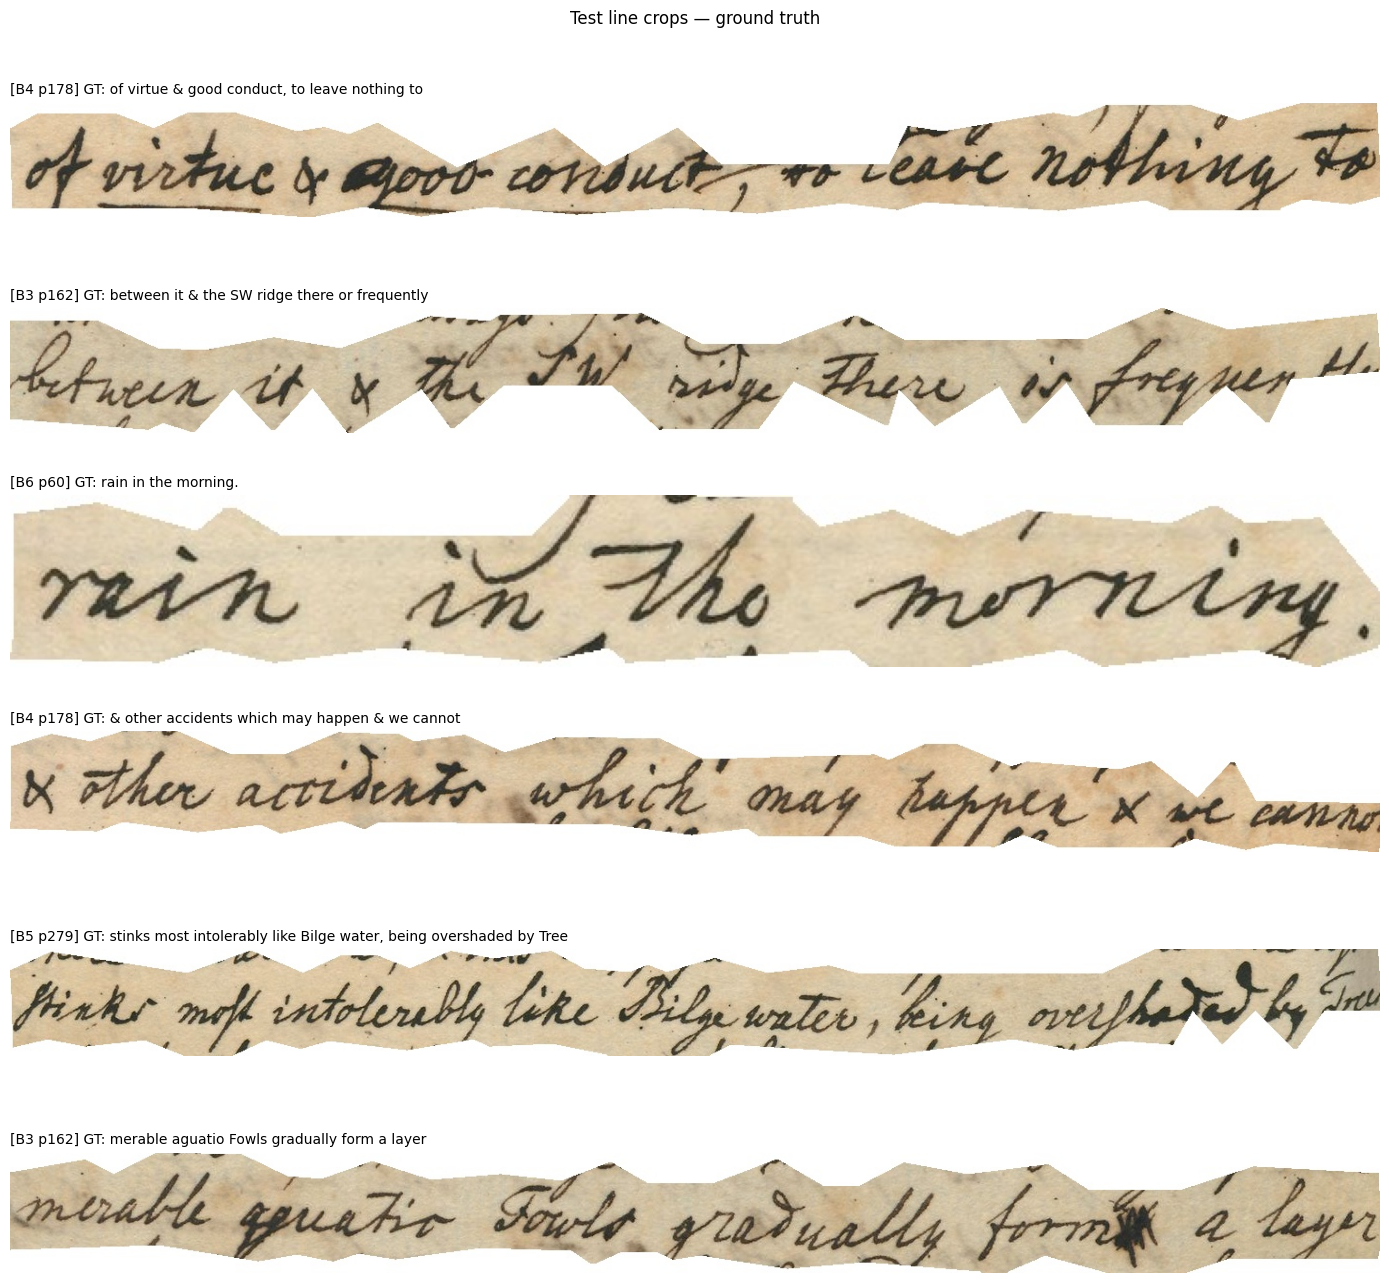

In [8]:
N_SHOW = 6
sample = test_df.sample(min(N_SHOW, len(test_df)), random_state=0).reset_index(drop=True)
fig, axes = plt.subplots(len(sample), 1, figsize=(14, 2.2 * len(sample)))
for ax, row in zip(axes, sample.itertuples()):
    ax.imshow(Image.open(row.file_name), cmap='gray')
    ax.set_title(f'[{row.book} p{row.page}] GT: {row.text}', fontsize=10, loc='left')
    ax.axis('off')
plt.suptitle('Test line crops — ground truth', y=1.0)
plt.tight_layout()
plt.show()

# Dataset, Model & Metrics

In [9]:
# Grayscale -> 3 channels, no augmentation (standard TrOCR eval preprocessing).
class LineOCRDataset(Dataset):
    def __init__(self, df, processor, transforms=None, max_target_length=128):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.transforms = transforms
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df['file_name'][idx]).convert('RGB')
        if self.transforms:
            image = self.transforms(image)
        pixel_values = self.processor(image, return_tensors='pt').pixel_values
        labels = self.processor.tokenizer(
            self.df['text'][idx],
            padding='max_length',
            max_length=self.max_target_length,
            truncation=True,
        ).input_ids
        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]
        return {'pixel_values': pixel_values.squeeze(), 'labels': torch.tensor(labels)}

eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
])

In [10]:
# Zero-shot: load BOTH the processor and the model straight from the base checkpoint.
processor  = TrOCRProcessor.from_pretrained(BASE_MODEL)
eval_model = VisionEncoderDecoderModel.from_pretrained(BASE_MODEL)

eval_model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
eval_model.config.pad_token_id           = processor.tokenizer.pad_token_id
eval_model.config.eos_token_id           = processor.tokenizer.sep_token_id
eval_model.config.vocab_size             = eval_model.config.decoder.vocab_size
eval_model.generation_config.max_length  = MAX_TARGET_LENGTH
eval_model.generation_config.num_beams   = NUM_BEAMS

eval_model.to(device)
eval_model.eval()
print('Model loaded:', BASE_MODEL)
print('train/val/test lines:', len(train_df), len(val_df), len(test_df))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: microsoft/trocr-base-handwritten
train/val/test lines: 726 194 189


In [11]:
cer_metric = evaluate.load('cer')
wer_metric = evaluate.load('wer')

# Zero-Shot Evaluation — CER / WER

`run_eval` generates predictions for any split and returns aligned `(preds, refs)` plus CER/WER.
We score the **test** set (the headline zero-shot number) and the **val** set (a baseline on the
pages reserved for early stopping).

In [12]:
def run_eval(df):
    ds = LineOCRDataset(df, processor, eval_transforms, MAX_TARGET_LENGTH)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=default_data_collator)
    eval_model.eval()
    preds, refs = [], []
    with torch.no_grad():
        for batch in loader:
            pixel_values = batch['pixel_values'].to(device)
            generated_ids = eval_model.generate(
                pixel_values, max_length=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS,
            )
            preds.extend(processor.batch_decode(generated_ids, skip_special_tokens=True))
            labels = batch['labels'].clone()
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs.extend(processor.batch_decode(labels, skip_special_tokens=True))
    cer = cer_metric.compute(predictions=preds, references=refs)
    wer = wer_metric.compute(predictions=preds, references=refs)
    return preds, refs, cer, wer

# Headline: zero-shot on the held-out TEST set
all_preds, all_refs, final_cer, final_wer = run_eval(test_df)
print(f'Zero-shot ({BASE_MODEL}) on TEST — {len(all_refs)} lines')
print(f'  CER: {final_cer:.4f}')
print(f'  WER: {final_wer:.4f}')

# Baseline: zero-shot on the VALIDATION set (last page of each book)
val_preds, val_refs, val_cer, val_wer = run_eval(val_df)
print(f'\nZero-shot on VAL (early-stopping pages) — {len(val_refs)} lines')
print(f'  CER: {val_cer:.4f}')
print(f'  WER: {val_wer:.4f}')

print('\nSample TEST predictions:')
for pred, ref in list(zip(all_preds, all_refs))[:10]:
    print(f'  GT  : {ref}')
    print(f'  PRED: {pred}\n')

Zero-shot (microsoft/trocr-base-handwritten) on TEST — 189 lines
  CER: 0.2637
  WER: 0.5694

Zero-shot on VAL (early-stopping pages) — 194 lines
  CER: 0.2494
  WER: 0.5502

Sample TEST predictions:
  GT  : 103
  PRED: 103

  GT  : pity that they were not capable enough
  PRED: a party that they were not capable enough

  GT  : of giving good scientific descriptions & accu-
  PRED: of giving good scientific defemptions from

  GT  : rate drawings of the many curious Animals
  PRED: rate drawings of the many curious Animals

  GT  : they had opportunitys to see on their
  PRED: they had opportunities to see on their

  GT  : Voyages.
  PRED: voyages .

  GT  : Sept. 3th Several Shoals of flying fish were
  PRED: topt-g. Several Shoals of flying fish seems .

  GT  : seen & a Bonito (Scomber Pelamys) was caught
  PRED: seen as a Bonito Colombes Selamps ) was coughs

  GT  : my Son finihed a drawing of it & we feasted
  PRED: my. I'm finished a drawing of 1/2 we fearted

  GT  : upon the

# Per-book CER / WER on the test set

In [13]:
rows = []
for i, (pred, ref) in enumerate(zip(all_preds, all_refs)):
    rows.append({'book': test_df['book'].iloc[i],
                 'cer': cer_metric.compute(predictions=[pred], references=[ref]),
                 'wer': wer_metric.compute(predictions=[pred], references=[ref])})
per_line_df = pd.DataFrame(rows)
by_book = per_line_df.groupby('book').agg(lines=('cer', 'size'),
                                          CER=('cer', 'mean'),
                                          WER=('wer', 'mean')).round(4)
print('Per-book zero-shot on TEST (mean over lines):')
print(by_book)
print(f'\nOverall TEST  — CER: {final_cer:.4f}  WER: {final_wer:.4f}  (n={len(all_refs)})')

Per-book zero-shot on TEST (mean over lines):
      lines     CER     WER
book                       
B1       24  0.1967  0.5779
B2       30  0.2074  0.5471
B3       32  0.3039  0.6082
B4       28  0.3323  0.6433
B5       39  0.3892  0.6509
B6       36  0.3322  0.7061

Overall TEST  — CER: 0.2637  WER: 0.5694  (n=189)


# Visualise sample test predictions with scores

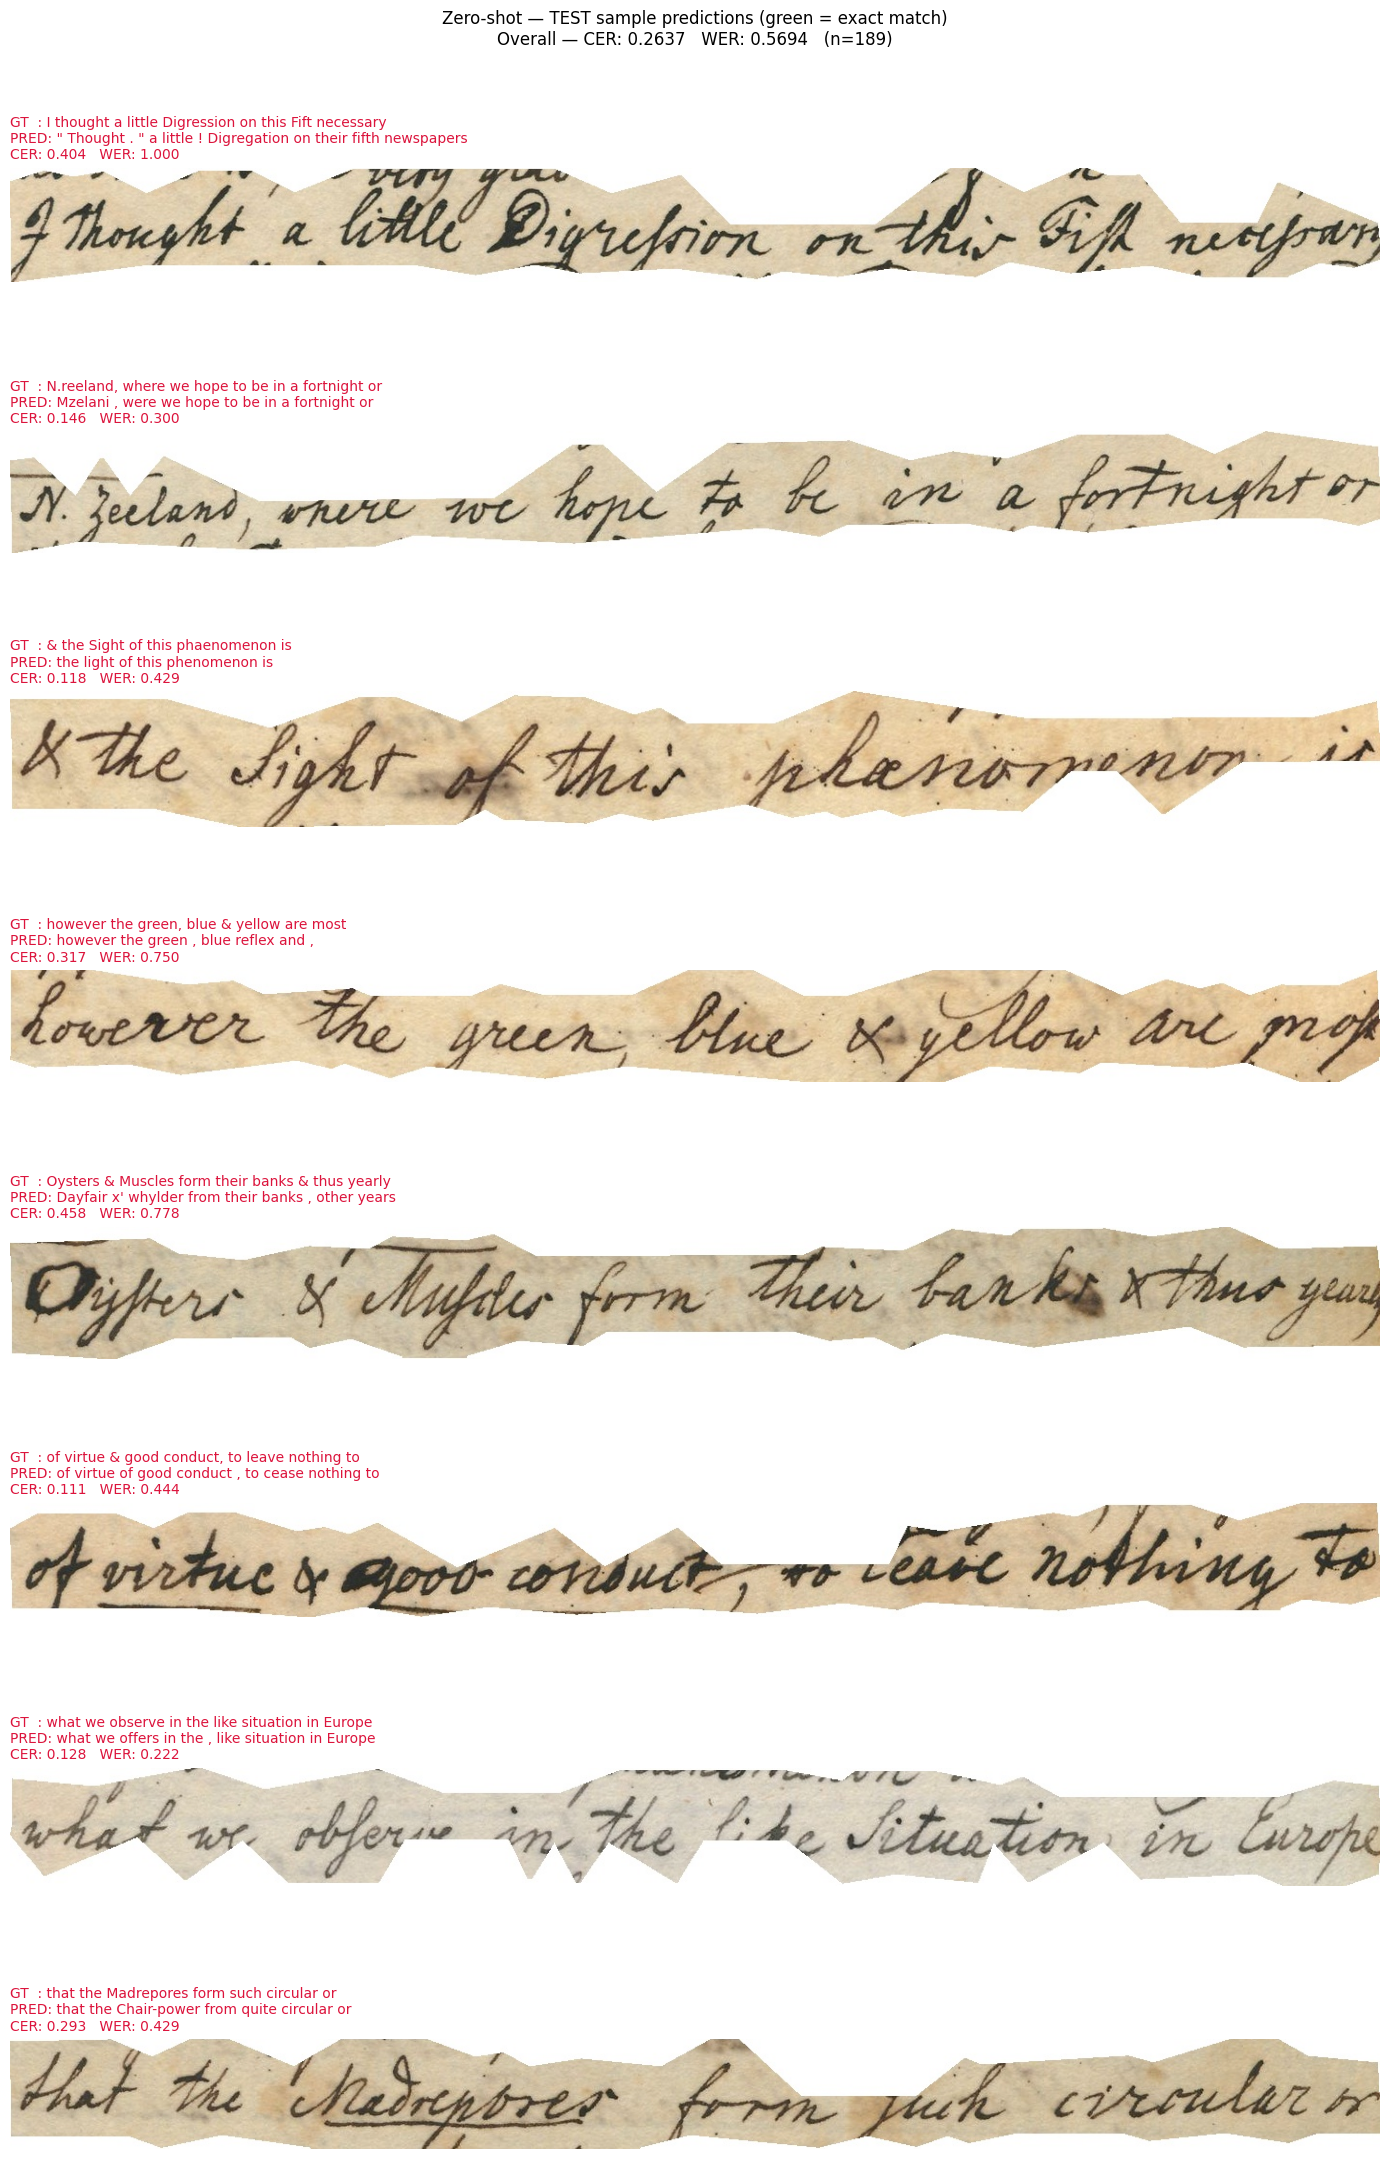

In [14]:
N_SHOW = 8
sample = test_df.sample(min(N_SHOW, len(test_df)), random_state=42).reset_index(drop=True)

eval_model.eval()
fig, axes = plt.subplots(len(sample), 1, figsize=(14, 2.8 * len(sample)))
if len(sample) == 1:
    axes = [axes]

with torch.no_grad():
    for ax, row in zip(axes, sample.itertuples()):
        image = Image.open(row.file_name).convert('RGB')
        proc_image = eval_transforms(image)
        pixel_values = processor(proc_image, return_tensors='pt').pixel_values.to(device)
        generated_ids = eval_model.generate(
            pixel_values, max_length=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS,
        )
        pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        line_cer = cer_metric.compute(predictions=[pred], references=[row.text])
        line_wer = wer_metric.compute(predictions=[pred], references=[row.text])
        match = pred.strip() == row.text.strip()
        ax.imshow(image, cmap='gray')
        ax.set_title(f'GT  : {row.text}\nPRED: {pred}\nCER: {line_cer:.3f}   WER: {line_wer:.3f}',
                     fontsize=10, loc='left', color='green' if match else 'crimson')
        ax.axis('off')

plt.suptitle(
    f'Zero-shot — TEST sample predictions (green = exact match)\n'
    f'Overall — CER: {final_cer:.4f}   WER: {final_wer:.4f}   (n={len(all_refs)})',
    y=1.0,
)
plt.tight_layout()
plt.show()

# 10 worst test predictions by CER

10 worst test lines by CER:
  CER 1.500  WER 1.000
    GT  : pond
    PRED: quizzi

  CER 1.500  WER 1.000
    GT  : tw
    PRED: thir

  CER 1.250  WER 1.000
    GT  : 1771
    PRED: plym.

  CER 1.125  WER 1.500
    GT  : Sea. Jan
    PRED: Peace change .

  CER 1.053  WER 2.000
    GT  : squeezes and wasted
    PRED: agree # even # supplies .

  CER 1.000  WER 2.000
    GT  : South
    PRED: smith .

  CER 1.000  WER 2.000
    GT  : some
    PRED: yime .

  CER 1.000  WER 1.000
    GT  : 79
    PRED: ty

  CER 1.000  WER 1.000
    GT  : 74
    PRED: 14.

  CER 1.000  WER 1.000
    GT  : 29
    PRED: 2g.



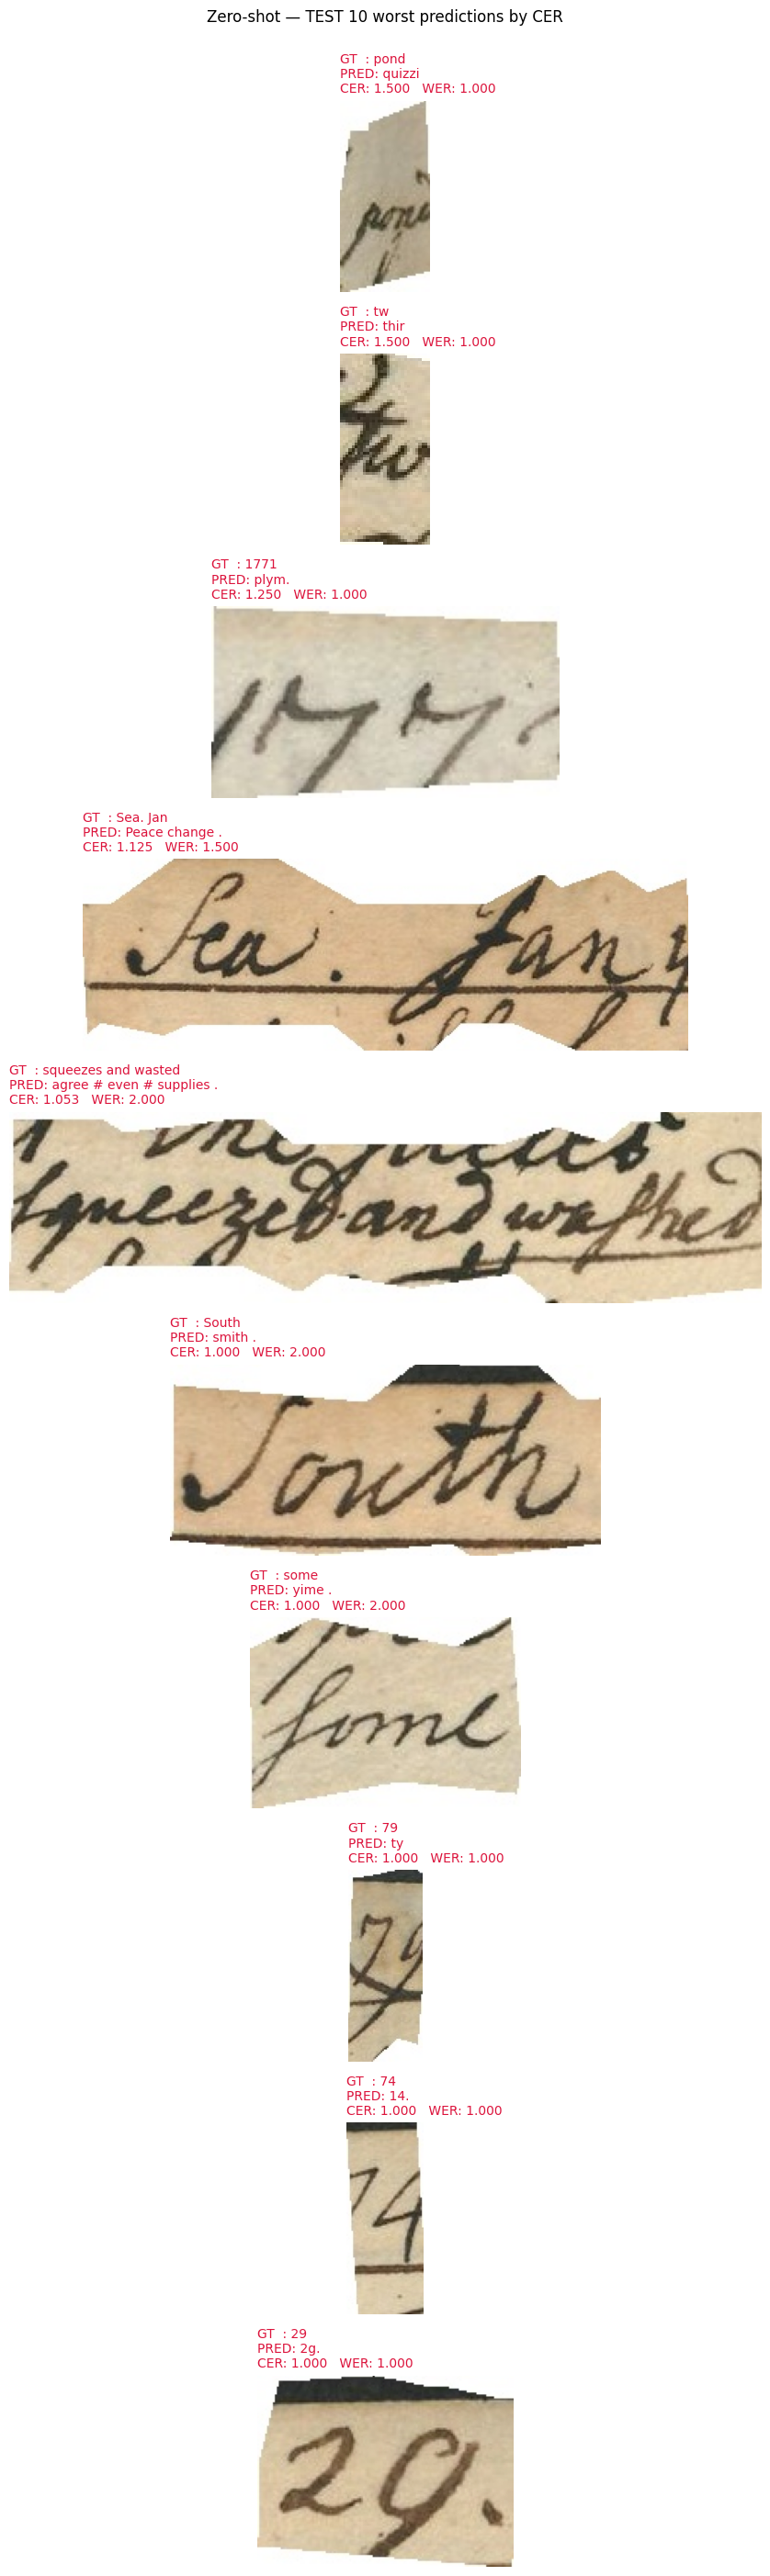

In [15]:
# all_preds / all_refs are aligned with test_df row order (DataLoader used shuffle=False).
assert len(all_preds) == len(test_df), 'Re-run the eval cell so all_preds aligns with test_df'

per_line = []
for i, (pred, ref) in enumerate(zip(all_preds, all_refs)):
    c = cer_metric.compute(predictions=[pred], references=[ref])
    w = wer_metric.compute(predictions=[pred], references=[ref])
    per_line.append({'idx': i, 'cer': c, 'wer': w,
                     'file_name': test_df['file_name'].iloc[i],
                     'gt': ref, 'pred': pred})

worst = sorted(per_line, key=lambda r: (r['cer'], r['wer']), reverse=True)[:10]

print('10 worst test lines by CER:')
for r in worst:
    print(f"  CER {r['cer']:.3f}  WER {r['wer']:.3f}")
    print(f"    GT  : {r['gt']}")
    print(f"    PRED: {r['pred']}\n")

fig, axes = plt.subplots(len(worst), 1, figsize=(14, 2.8 * len(worst)))
if len(worst) == 1:
    axes = [axes]
for ax, r in zip(axes, worst):
    ax.imshow(Image.open(r['file_name']).convert('RGB'), cmap='gray')
    ax.set_title(f"GT  : {r['gt']}\nPRED: {r['pred']}\nCER: {r['cer']:.3f}   WER: {r['wer']:.3f}",
                 fontsize=10, loc='left', color='crimson')
    ax.axis('off')
plt.suptitle('Zero-shot — TEST 10 worst predictions by CER', y=1.0)
plt.tight_layout()
plt.show()

# (Optional) Fine-tune with early stopping on the validation set

The zero-shot test above needs no training. This section shows how the **validation set** drives
**early stopping** and best-checkpoint selection once you fine-tune — it is the whole reason the
last-page-per-book split was converted to `val`.

Key `Seq2SeqTrainingArguments`:
- `eval_strategy='epoch'` + `save_strategy='epoch'` — score val CER every epoch,
- `metric_for_best_model='cer'`, `greater_is_better=False` — lower val CER is better,
- `load_best_model_at_end=True` — restore the best checkpoint after training,
- `EarlyStoppingCallback(early_stopping_patience=3)` — stop if val CER does not improve for 3 evals.

It is gated behind `RUN_FINETUNE = False`, so running the whole notebook only does the zero-shot
test. Flip it to `True` to fine-tune.

In [16]:
RUN_FINETUNE = False   # set True to fine-tune the base model with early stopping on val_df

if RUN_FINETUNE:
    from transformers import (Seq2SeqTrainer, Seq2SeqTrainingArguments,
                              EarlyStoppingCallback)

    # Light augmentation for training; clean grayscale for eval.
    train_transforms = transforms.Compose([transforms.Grayscale(num_output_channels=3)])
    train_ds = LineOCRDataset(train_df, processor, train_transforms, MAX_TARGET_LENGTH)
    val_ds   = LineOCRDataset(val_df,   processor, eval_transforms,  MAX_TARGET_LENGTH)

    model = VisionEncoderDecoderModel.from_pretrained(BASE_MODEL)
    model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
    model.config.pad_token_id           = processor.tokenizer.pad_token_id
    model.config.eos_token_id           = processor.tokenizer.sep_token_id
    model.config.vocab_size             = model.config.decoder.vocab_size
    model.generation_config.max_length  = MAX_TARGET_LENGTH
    model.generation_config.num_beams   = NUM_BEAMS

    def compute_metrics(pred):
        pred_ids = pred.predictions
        label_ids = pred.label_ids
        label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
        pred_str  = processor.batch_decode(pred_ids, skip_special_tokens=True)
        label_str = processor.batch_decode(label_ids, skip_special_tokens=True)
        return {'cer': cer_metric.compute(predictions=pred_str, references=label_str),
                'wer': wer_metric.compute(predictions=pred_str, references=label_str)}

    training_args = Seq2SeqTrainingArguments(
        output_dir='/content/drive/MyDrive/transcriptions_splits/trocr_finetune',
        predict_with_generate=True,
        eval_strategy='epoch',
        save_strategy='epoch',
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=5e-5,
        num_train_epochs=20,
        fp16=(DEVICE_TYPE == 'cuda'),
        logging_steps=50,
        load_best_model_at_end=True,        # restore the best (lowest val CER) checkpoint
        metric_for_best_model='cer',
        greater_is_better=False,
        save_total_limit=2,
        seed=42,
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,                # <- validation set drives early stopping
        data_collator=default_data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    trainer.train()
    print('Best checkpoint restored (lowest val CER). Re-run run_eval(test_df) to score the test set.')
else:
    print('RUN_FINETUNE is False — zero-shot test only. Set it to True to fine-tune.')

RUN_FINETUNE is False — zero-shot test only. Set it to True to fine-tune.


# Emit results for cross-experiment comparison

Prints a compact JSON block (test CER/WER, per-book scores, training history) to this cell's
**output**, wrapped in `RESULT_JSON_BEGIN` / `RESULT_JSON_END` markers. The comparison notebook
(`compareExperimentResults.ipynb`) reads this `.ipynb` file directly and parses the block — no
JSON files on Drive are involved. Just re-download / commit this notebook after running it.

In [ ]:
# Emit results for the comparison notebook to read straight from THIS notebook's output.
# No Drive round-trip: compareExperimentResults.ipynb parses the printed block below.
import json
result = {
    'experiment': 'zero_shot_base',
    'label': 'Zero-shot (base TrOCR)',
    'model': BASE_MODEL,
    'test': {'cer': float(final_cer), 'wer': float(final_wer), 'n': int(len(all_refs))},
    'per_book': by_book.reset_index().rename(columns={'CER':'cer','WER':'wer'}).to_dict('records'),
    'val':  {'cer': float(val_cer), 'wer': float(val_wer), 'n': int(len(val_refs))},
    'history': None,   # no training in zero-shot
}
print('RESULT_JSON_BEGIN')
print(json.dumps(result, indent=2))
print('RESULT_JSON_END')
